<a href="https://colab.research.google.com/github/adityadhanraj24/Python-A-learning-hub/blob/main/01_PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch WorkFlow


In [ ]:
what_were_covering={
    1:"Data(prepare and load)",
    2:"Building Model",
    3:"Fitting the model to data(Training)",
    4:"Making predictions and evaluting a model(inference)",
    5:"Saving and loading a model",
    6:"Putting it all together"
}
what_were_covering

{1: 'Data(prepare and load)',
 2: 'Building Model',
 3: 'Fitting the model to data(Training)',
 4: 'Making predictions and evaluting a model(inference)',
 5: 'Saving and loading a model',
 6: 'Putting it all together'}

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

#Check PyTorch version
torch.__version__

'2.11.0+cpu'

### 1. Data (Preparing and Loading)
Data can be almost anything.... in machine learning.


*   Excel Spreadsheet
*   Images of any kind
*   Videos,Audios,DNA,Text

Machine Learning is a game of two parts:


1.  Get data into a numerical repersentation.
2. Build a model to learn patterns in that numerical repersentation.

To showcase this, let's create some *known* data using a linear regression formula.

We will use a linear regression formula to make a straight line with known parameters.






In [ ]:
# Create Known parameters
weight=0.9
bias=0.3

# Create
start=0
end=1
step=0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X + bias

X[:10], y[:10],len(X),len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3180],
         [0.3360],
         [0.3540],
         [0.3720],
         [0.3900],
         [0.4080],
         [0.4260],
         [0.4440],
         [0.4620]]),
 50,
 50)

In [ ]:
len(X),len(y)

(50, 50)

Training Set ( Modes Learns From Here e.g. Course Exam) ---> Validation Set (Tune Models Patterns , e.g. Practice exam) -----> Test Set (See if the model is ready for the wild e.g., Final Exam).

### Generalization: The ability for a machine learning model to perform well on data it hasnot seen

## Splitting data into training and test sets
Let's create a training and test set with our data

In [ ]:
#Create a train/test split
train_split=int(0.8*len(X))
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

How might we better visualize our data?
Using Matplotlib

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,predictions=None):

  """
  Plots Training Data ,test data and compares predictions

  """
  plt.figure(figsize=(10,7))

# Plot training data in blue

  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")

# Plot test data in green

  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

# Are there predictions
  if predictions is not None:
  # Plot the predictions if they exist
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

# Show the legend
  plt.legend(prop={"size":14});



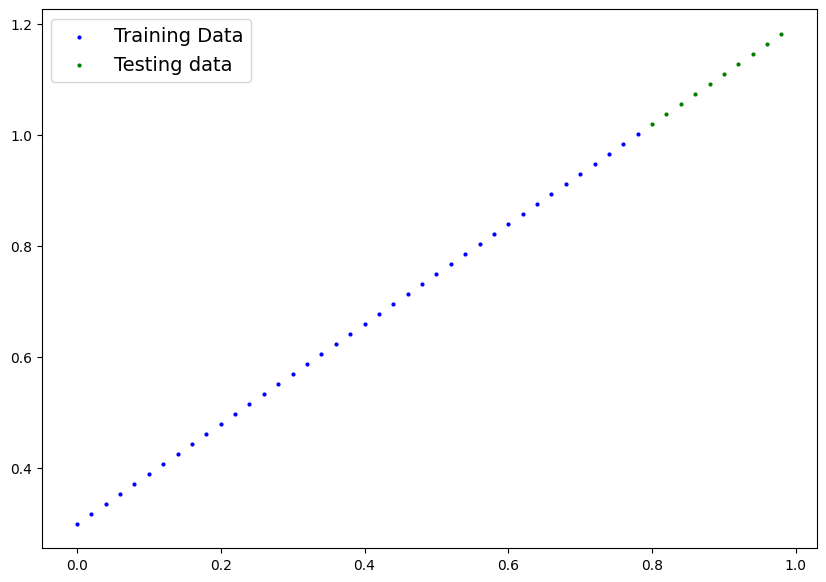

In [ ]:
plot_predictions()

## Build PyTorch Model
### Our first Pytorch Model!!

In [ ]:
# Create linear regression model

class LinearRegressionModel(nn.Module):  #<-almost everything in PyTorch inherts from nn.Module
  def __init__(self) -> None:
    super().__init__()
    self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

    self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))

    # Forward Method to define the compuation in the model
  def forward(self,x: torch.Tensor) -> torch.Tensor: #<-"x" is the input data
    return self.weights*x + self.bias # This is the linear regression formula

## What our model does
 *  Start with random value (weight & Bias)
 *  Look at training data and adjust the random values to better repersent (or get closer to) the ideal values (the weight & bias values we used to create the data)

## How does it do so?
Through two main algorithms:
*  Gradient Descent
*  Backpropagation


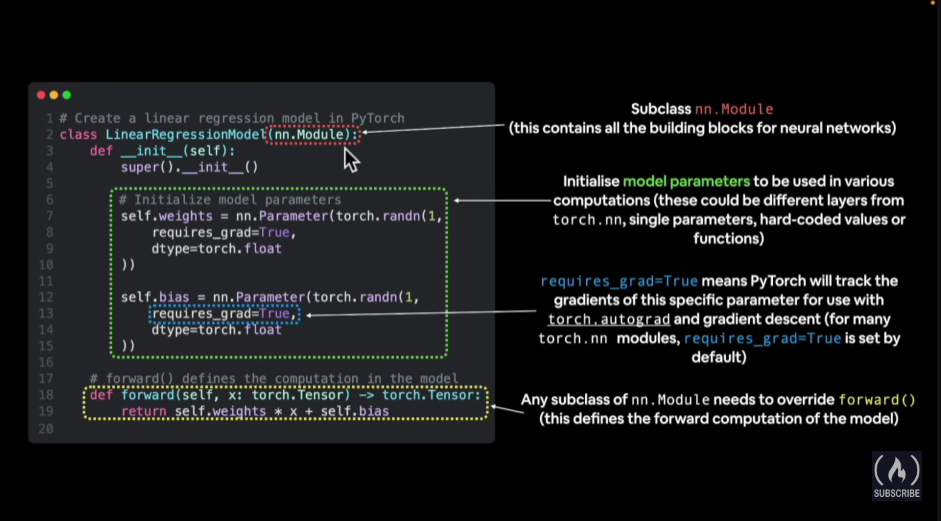

## PyTorch model building essentials
* torch.nn :- Contains all of the buildings for computational graphs(a neural network can be considered a computational graph)
* torch.nn.Parameter-what parameters should our model try and learn , often a PyTorch layer from torch.nn will set these for us
* torch.nn.Module- The base class for all neural network module, if you subclass it, you should overwrite forward().
* torch.optim-This where the optimizers in PyTorch live, they will help with gradient descent
* def forward()-All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation.


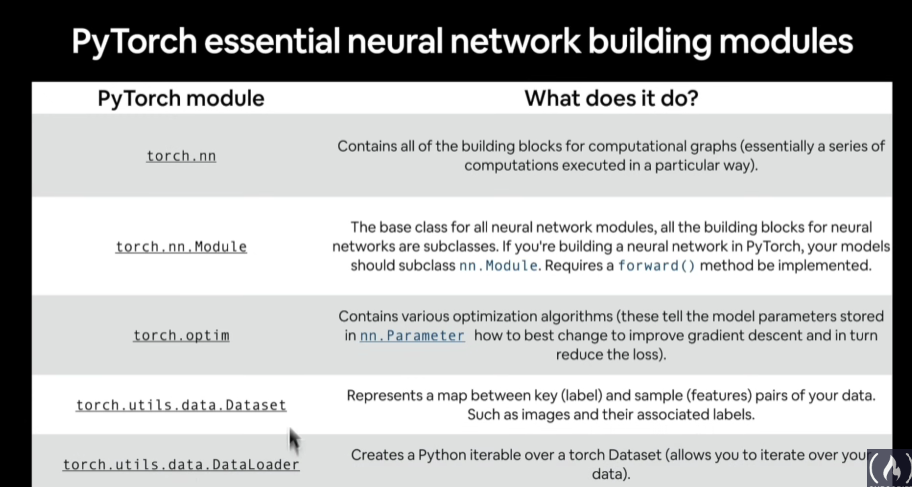

In [ ]:
#Create a random seed
torch.manual_seed(42)

# Create an instance of the model (This is a subclass of nn.Module)
model_0=LinearRegressionModel()
# Checkout the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
torch.manual_seed(40)
torch.randn(1)

tensor([0.9307])

In [ ]:
# List named parameters
model_0.state_dict()


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `tensor.inference_model()`

To check our model's predictive power, let's see how well it predict `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [ ]:
# Now you can make predictions safely
with torch.inference_mode():
  y_preds = model_0(X_test)


y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [ ]:
y_test = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

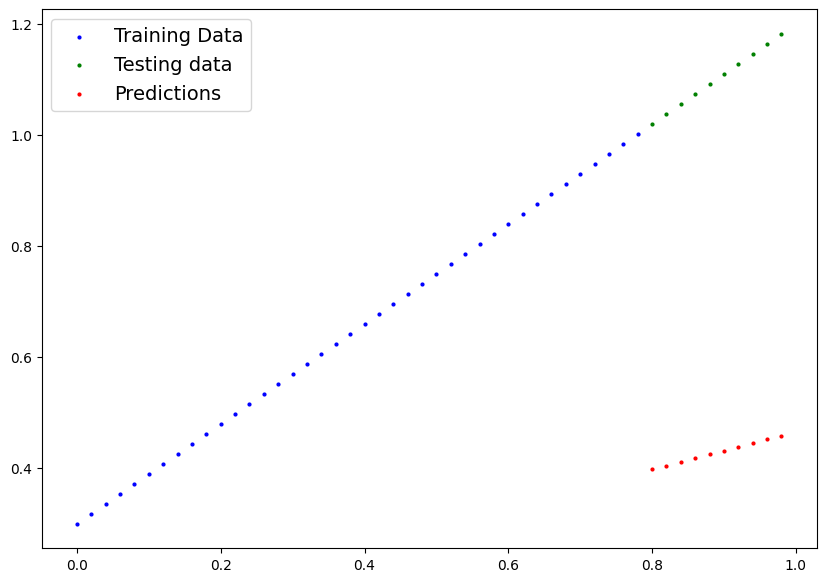

In [ ]:
plot_predictions(predictions=y_preds)

## 3. Train Model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

Or in other words from a poor repersentation of the data to a better repersentation of the data.

One way to measure how poor or wrong your models predictions are is to use a loss function.


* Note: Loss function may also be called as cost function or criterion in different areas. For our case , we are going to refer to it as a loss function.

* **Loss Function :** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.

* **Optimize :** Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias) to improve the loss function.
  
   *   Inside the optimizer you will often have to set two parameters:

       *   params:- the model parameters you had like to optimize, for example params=model_0.parameters().
       
       *   lr(learning rate) : the learning rate is hyperparameter that defines hoow big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes).

And specifically for PyTorch, we need:

*   A training loop
*   A testing loop




In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Setup a loss function

loss_fn=nn.L1Loss()


# Setup an optimizer(stochastic gradient descent)
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01) # lr=learning rate = possibly the most important hyperparameter you can set .




**Q:** Which loss function and optimizer should i use?

**A:** For a linear regression problem , a loss function of nn.L1Loss() and an optimizer like torch.optim.SGD() will sufficient.
For classification problem like classifying whether a photo is of a dog or a cat , we will likely want to use a loss function of *nn.BCELoss()* (Binary Cross Entropy loss).

### Building a training loop (and a testing loop)in PyTorch

A couple of things we need in training loop:

1.  Loop Through the data
2.  Forward pass (this involves data moving through our model's `forward()`functions) to make predictions on data - also called forward propagation.
3. Calculate the loss (compare forward pass predictions to ground truth labels).
4. optimizer zero grad.
5. Loss backward : move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**).
6. Optimizer Step : use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**).





In [ ]:
# with torch.inference_mode():
# # with torch.no_grad():
#   list(model_0.parameters())

In [ ]:
# list(model_0.parameters())

In [ ]:
# An epoch is one loop through the data...
torch.manual_seed(42)
epochs=200

epoch_count=[]
loss_values=[]
test_loss_values=[]
train_loss_values=[]

### Trainig
# 0. Loop through the data

for epoch in range(epochs):
  # Set the model to training mode
  model_0.train()  # train mode in PyTorch sets all parameters that require gradients to require gradients.

  # 1. Forward pass
  y_pred=model_0(X_train)

  # 2.Calculate the loss
  loss = loss_fn(y_pred,y_train)
  # print(f"Loss:{loss}")

  # 3. Optimizer zero grad()
  optimizer.zero_grad()

  # 4. Perform backpropagation on the loss with respect to the parameter of the model
  loss.backward()

  #5. Step the optimizer (Perform gradient descent)
  optimizer.step()

  # Testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing
  with torch.inference_mode():
  # with torch.no_grad():
    # 1. Do the forward pass
    test_pred=model_0(X_test)

    #2. Calculate Loss
    test_loss=loss_fn(test_pred,y_test)
    # Print out whats happening
  if epoch%10==0:
     epoch_count.append(epoch)
     loss_values.append(loss.item())
    #  test_loss_values.append(test_loss)
     test_loss_values.append(test_loss.item())
     train_loss_values.append(loss.item())
     print(f"Epoch:{epoch} | Loss: {loss} | Test loss:{test_loss}")

     print(model_0.state_dict())

Epoch:0 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:10 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:20 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:30 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:40 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:50 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:60 | Loss: 0.00553224328905344 | Test loss:0.6774704456329346
OrderedDict({'weights': tensor([0.8979]), 'bias': tensor([0.3068])})
Epoch:70 | Loss: 0.00553224328905344 | Tes

In [ ]:
import numpy as np
np.array(torch.tensor(loss_values).numpy()),test_loss_values
# epoch_count,loss_values,test_loss_values

(array([0.00553224, 0.00553224, 0.00553224, 0.00553224, 0.00553224,
        0.00553224, 0.00553224, 0.00553224, 0.00553224, 0.00553224,
        0.00553224, 0.00553224, 0.00553224, 0.00553224, 0.00553224,
        0.00553224, 0.00553224, 0.00553224, 0.00553224, 0.00553224],
       dtype=float32),
 [0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346])

In [ ]:
loss_values,test_loss_values

([0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344,
  0.00553224328905344],
 [0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346,
  0.6774704456329346])

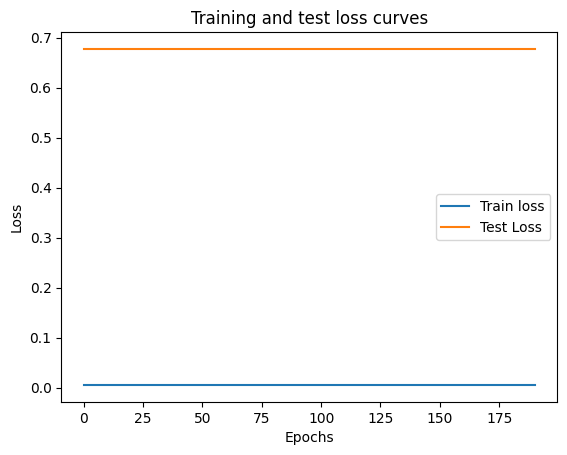

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()),label="Train loss")
plt.plot(epoch_count,test_loss_values,label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")

plt.legend();

In [ ]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8940])), ('bias', tensor([0.2968]))])

In [ ]:
weight,bias

(0.9, 0.3)

###PyTorch Optimization Remember Trick
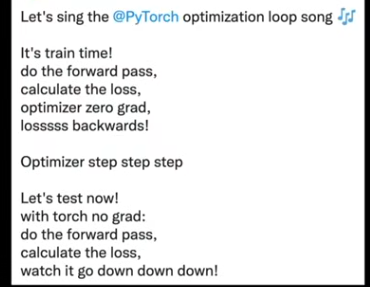

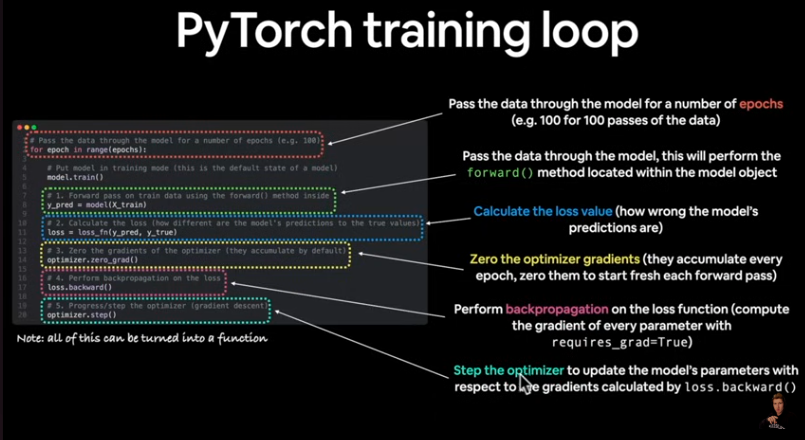

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8940])), ('bias', tensor([0.2968]))])

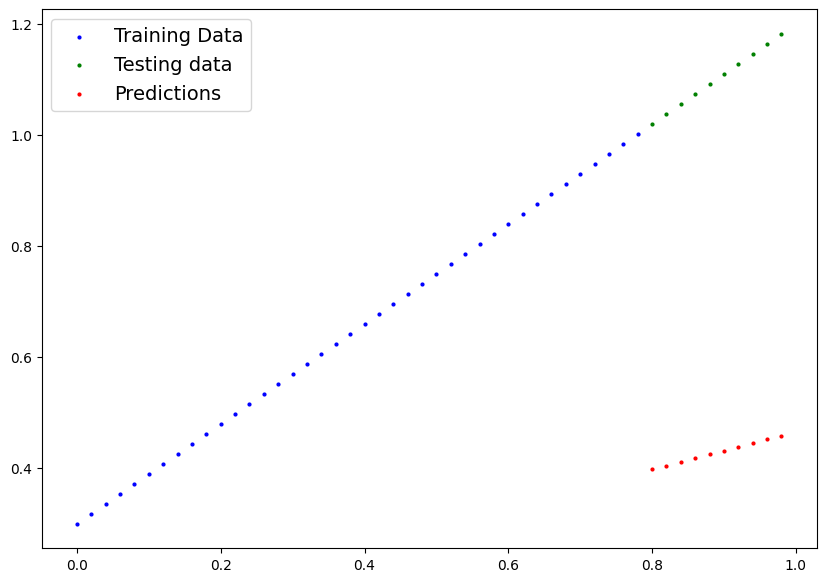

In [ ]:
plot_predictions(predictions=y_preds);

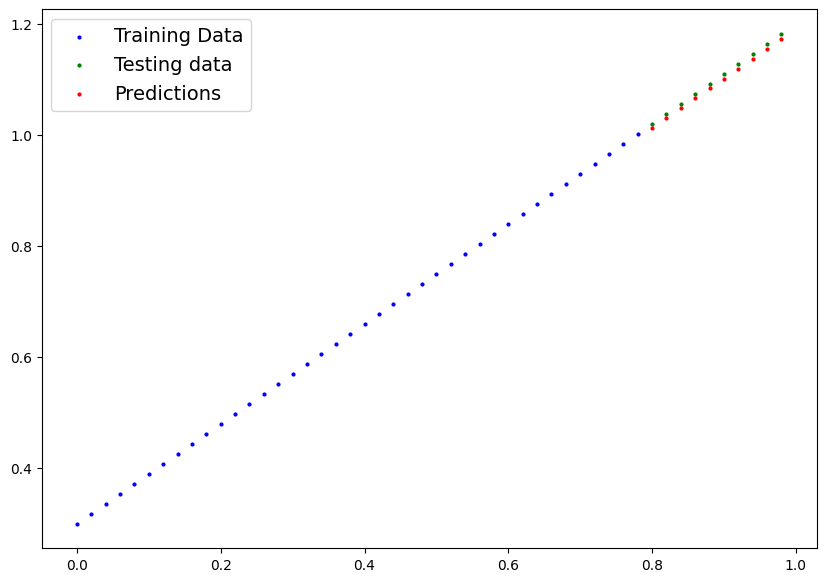

In [ ]:
plot_predictions(predictions=y_preds_new);

### Saving the model in PyTorch

There are three main methods you should know  about for saving and loading models in PyTorch.



1.   `torch.save()`-allows you save a PyTorch object in Python's pickle format
2.   `torch.load()`- allows you load a saved PyTorch object.
3.  `torch.nn.Module.load_state_dict()`- this allows to load a model's saved state dictionary


**Saving and loading models study from documentation of pytorch**


In [ ]:
# Saving our PyTorch model

from pathlib import Path

# 1. create models directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. Create model save path
MODEL_NAME="01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

MODEL_SAVE_PATH

#3. Save the model static dict
print(f"Saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)


Saving model to :models/01_pytorch_workflow_model_0.pth


In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 2117 Jul 15 06:04 01_pytorch_workflow_model_0.pth


## Loading a PyTorch Model

Since we saved our model's state_dict() rather than the entire model , we will create a new instance of our model class and load the saved state_dict() into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.8940])), ('bias', tensor([0.2968]))])

In [ ]:
# To load in a saved state_dict we have to instatiate a new instance of our model class
loaded_model_0=LinearRegressionModel()

#Load the saved state_dict of model_0 (this will update the new instance with updated parameter)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.8940])), ('bias', tensor([0.2968]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
   loaded_model_preds=loaded_model_0(X_test)

loaded_model_preds

tensor([[1.0120],
        [1.0299],
        [1.0478],
        [1.0656],
        [1.0835],
        [1.1014],
        [1.1193],
        [1.1372],
        [1.1550],
        [1.1729]])

In [ ]:
# Compare loaded model preds with original model treds
y_preds==loaded_model_preds

#Make some models preds

model_0.eval()
with torch.inference_mode():
  y_preds=model_0(X_test)

y_preds

tensor([[1.0120],
        [1.0299],
        [1.0478],
        [1.0656],
        [1.0835],
        [1.1014],
        [1.1193],
        [1.1372],
        [1.1550],
        [1.1729]])

In [ ]:
y_preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [ ]:
# import pytorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

In [ ]:
# Setup device agostic mode
device="cuda" if torch.cuda.is_available() else "cpu"
print(f"Using devices:{device}")

Using devices:cpu


In [ ]:
# create some data using the linaer regression formula   y=w*X+bias

weight=0.7
bias=0.3

start=0
end=1
step=0.02

X=torch.arange(start,end,step).unsqueeze(dim=1)  # without uunsqueeze errors will popup
y=weight*X + bias
X[:10],y[:10]



(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# split data
train_split=int(0.8*len(X))
X_train,y_train= X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,predictions=None):

  """
  Plots Training Data ,test data and compares predictions

  """
  plt.figure(figsize=(10,7))

# Plot training data in blue

  plt.scatter(train_data,train_labels,c="b",s=4,label="Training Data")

# Plot test data in green

  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

# Are there predictions
  if predictions is not None:
  # Plot the predictions if they exist
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

# Show the legend
  plt.legend(prop={"size":14});


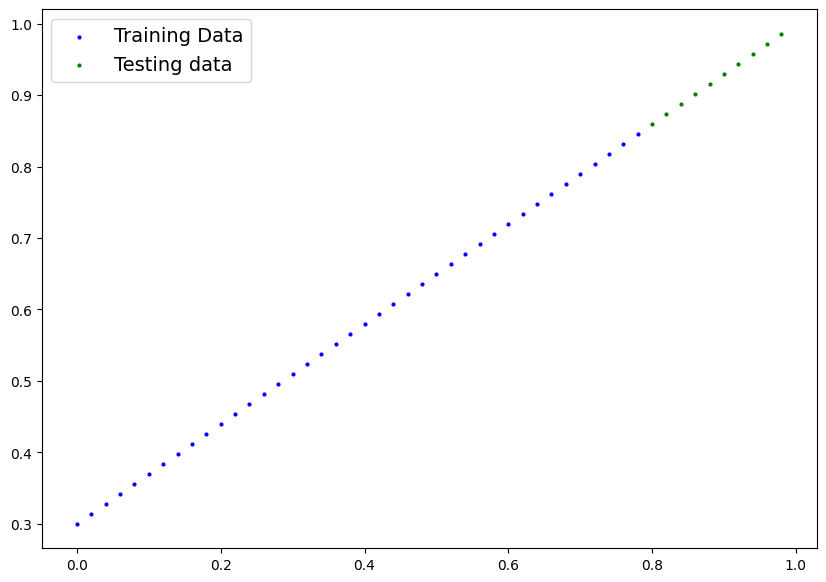

In [ ]:
# Plot the data
# Note: if you donot have the plot predictions() function loaded , this will error
plot_predictions(X_train,y_train,X_test,y_test)

In [ ]:
## Buildiing PyTorch Linear model
## creating a linear model by subclassing nn.Module

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer=nn.Linear(in_features=1,
                                out_features=1)



  def forward(self,X:torch.Tensor) ->torch.Tensor:
    return self.linear_layer(X)

torch.manual_seed(42)
model_1 =LinearRegressionModelV2()
model_1,model_1.state_dict()


(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
X_train[:5],y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [ ]:
# Check the model current device

next(model_1.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
## Training
## We need : Loss function,optimizer,training loop , testing loop

In [ ]:
# Setup Loss Function

loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer

optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.01)


In [ ]:
# Lets write a training loop
torch.manual_seed(42)
epochs=200

for epoch in range(epochs):
  model_1.train()

  #1. Forward pass
  y_pred=model_1(X_train)

  #2.Calculate the loss
  loss=loss_fn(y_pred,y_train)

  #3. Optimizer zero grad
  optimizer.zero_grad()

  #4. Perform Backpropagation
  loss.backward()

  #5. Optimizer step
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
   test_pred=model_1(X_test)

   test_loss=loss_fn(test_pred,y_test)

   #Print out whats happpening

  if epoch % 10 == 0:
    print(f"Epoch:{epoch}| Loss:{loss} | Test loss:{test_loss}")





Epoch:0| Loss:0.5551779866218567 | Test loss:0.5739762187004089
Epoch:10| Loss:0.4399680495262146 | Test loss:0.4392663538455963
Epoch:20| Loss:0.3247582018375397 | Test loss:0.30455657839775085
Epoch:30| Loss:0.20954827964305878 | Test loss:0.16984674334526062
Epoch:40| Loss:0.09433844685554504 | Test loss:0.03513689711689949
Epoch:50| Loss:0.023886386305093765 | Test loss:0.04784906655550003
Epoch:60| Loss:0.0199567973613739 | Test loss:0.04580312222242355
Epoch:70| Loss:0.016517987474799156 | Test loss:0.0375305712223053
Epoch:80| Loss:0.013089170679450035 | Test loss:0.029944902285933495
Epoch:90| Loss:0.009653178043663502 | Test loss:0.02167237363755703
Epoch:100| Loss:0.006215679459273815 | Test loss:0.014086711220443249
Epoch:110| Loss:0.002787243574857712 | Test loss:0.005814164876937866
Epoch:120| Loss:0.0012645035749301314 | Test loss:0.013801807537674904
Epoch:130| Loss:0.0012645035749301314 | Test loss:0.013801807537674904
Epoch:140| Loss:0.0012645035749301314 | Test loss:0

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
weight,bias

(0.7, 0.3)

## Making and Evaluating Predictions

In [ ]:
# Turn model into evaluation mode

model_1.eval()

# Make predictions on the test data

with torch.inference_mode():
  y_preds=model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

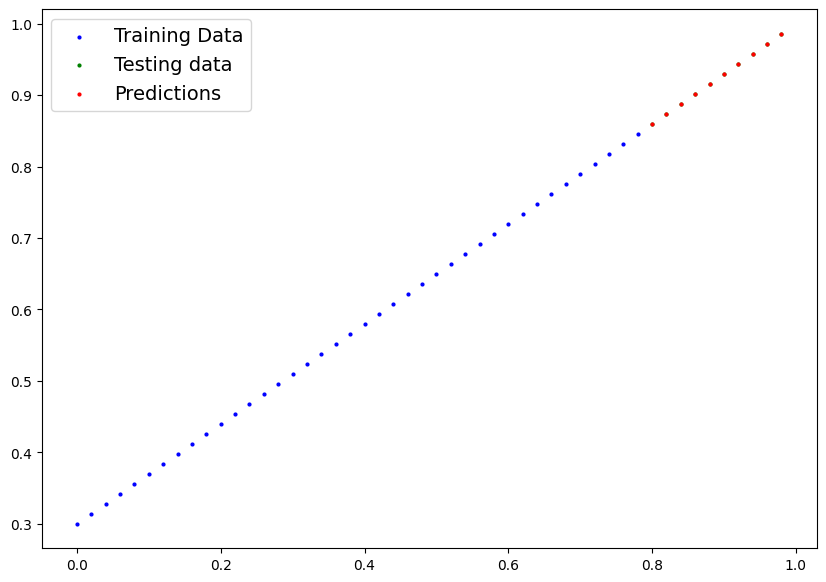

In [ ]:
# Check out our model predictions visually

plot_predictions(predictions=y_preds.cpu())

### Saving and Loading trained Model

In [ ]:
# Saving our PyTorch model

from pathlib import Path

# 1. create models directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. Create model save path
MODEL_NAME="01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

MODEL_SAVE_PATH

# #3. Save the model state dict
print(f"Saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)


Saving model to :models/01_pytorch_workflow_model_1.pth


In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
## Loading a PyTorch Model

# To load in a saved state_dict we have to instatiate a new instance of our model class
loaded_model_1=LinearRegressionModelV2()

#Load the saved state_dict of model_0 (this will update the new instance with updated parameter)
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_1.to(device)



LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cpu')

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [ ]:
# Evaluate Loaded Model

loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds=loaded_model_1(X_test)

y_preds== loaded_model_1_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])